In [1]:
import subprocess, os, shutil

REPO_URL = "https://github.com/safety-research/legibility.git"
REPO_DIR = "/workspace/18-4-2026"
EXP_DIR = os.path.join(REPO_DIR, "experiments", "2026", "15-4-2026")

# Clone or pull latest (fetch + reset to ensure we have the newest commit)
if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)

# Install git-lfs if not available, then pull LFS files
if shutil.which("git-lfs") is None:
    subprocess.run(["apt-get", "update", "-qq"], check=False)
    subprocess.run(["apt-get", "install", "-y", "-qq", "git-lfs"], check=False)
    subprocess.run(["git", "lfs", "install"], check=False)
subprocess.run(["git", "-C", REPO_DIR, "lfs", "pull"], check=False)

# Install dependencies
req_path = os.path.join(EXP_DIR, "requirements.txt")
if os.path.exists(req_path):
    subprocess.run(["pip", "install", "-q", "-r", req_path], check=True)
else:
    print(f"WARNING: {req_path} not found, skipping pip install")

# Set working directory so Path.cwd().parent resolves to experiment root
os.chdir(os.path.join(EXP_DIR, "notebooks"))

HEAD is now at 2ab22ca Add classification results for all 5 transform strategies


# NB8: G1 vs G3 Activation Comparison (Experiments F1/F2)

**CPU notebook** (~15 min). Compares activation profiles between G1 (DeepSeek-R1-Distill,
pure RL computational think blocks) and G3 (QwQ-32B, different pipeline).

**F1**: Cosine similarity and norm comparison across layers for matched legible CoTs.
**F2**: Probes to distinguish G1 vs G3 during legible reasoning.

**Note:** This compares G1 vs G3 (different pipelines), not G1 vs G2 (same pipeline,
different narration). A behavioral G1-vs-G2 comparison (Exp F3) can be added later via API.

**Requires:** NB1 outputs (`activations/{G1,G3}_last_token/`)

In [2]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import (
    load_activations, load_phase1_results, join_cots_with_labels,
    train_binary_probe, permutation_test, bootstrap_ci_metric,
    plot_layer_probe_curve, ACTIVATIONS_DIR, PHASE2_RESULTS_DIR,
)

PHASE2_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Checkpoint: check if final output already exists
_output_path = PHASE2_RESULTS_DIR / 'narration_results.json'
if _output_path.exists():
    import json as _json
    with open(_output_path) as _f:
        _saved = _json.load(_f)
    print(f"CACHED: {_output_path} exists.")
    for key in _saved:
        if isinstance(_saved[key], dict):
            print(f"  {key}: {len(_saved[key])} entries")
        else:
            print(f"  {key}: {_saved[key]}")
    print("Delete this file and re-run to recompute.")

CACHED: /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/narration_results.json exists.
  f1_cosine: 17 entries
  f1_norms: 17 entries
  f2_generator_probe: 17 entries
  n_matched_legible: 20
Delete this file and re-run to recompute.


In [4]:
# Load last-token activations for both models
g1_last = load_activations(ACTIVATIONS_DIR / "G1_last_token")
g3_last = load_activations(ACTIVATIONS_DIR / "G3_last_token")

with open(ACTIVATIONS_DIR / "G1_last_token" / "metadata.json") as f:
    g1_meta = json.load(f)
with open(ACTIVATIONS_DIR / "G3_last_token" / "metadata.json") as f:
    g3_meta = json.load(f)

g1_labels = [s[3] for s in g1_meta['sample_ids']]
g3_labels = [s[3] for s in g3_meta['sample_ids']]
g1_sids = [s[0] for s in g1_meta['sample_ids']]
g3_sids = [s[0] for s in g3_meta['sample_ids']]

print(f"G1: {len(g1_labels)} samples, layers={sorted(g1_last.keys())}")
print(f"G3: {len(g3_labels)} samples, layers={sorted(g3_last.keys())}")

# Common layers
common_layers = sorted(set(g1_last.keys()) & set(g3_last.keys()))
print(f"Common layers: {common_layers}")

G1: 219 samples, layers=[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 63]
G3: 229 samples, layers=[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 63]
Common layers: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 63]


## Experiment F1: Cosine Similarity and Norm Comparison

For matched legible CoTs (same question, both G1 and G3 produced legible reasoning),
compare activation profiles.

In [5]:
# Find matched legible pairs: same question, both models produced legible CoTs
g1_legible_sids = {g1_sids[i] for i, l in enumerate(g1_labels) if l == 'REASONING_LEGIBLE'}
g3_legible_sids = {g3_sids[i] for i, l in enumerate(g3_labels) if l == 'REASONING_LEGIBLE'}
matched_sids = g1_legible_sids & g3_legible_sids

print(f"G1 legible questions: {len(g1_legible_sids)}")
print(f"G3 legible questions: {len(g3_legible_sids)}")
print(f"Matched legible questions: {len(matched_sids)}")

# Get indices for matched samples
g1_matched_idx = [i for i, s in enumerate(g1_sids) if s in matched_sids and g1_labels[i] == 'REASONING_LEGIBLE']
g3_matched_idx = [i for i, s in enumerate(g3_sids) if s in matched_sids and g3_labels[i] == 'REASONING_LEGIBLE']

# Sort both by sample_id for alignment
g1_matched_idx = sorted(g1_matched_idx, key=lambda i: g1_sids[i])
g3_matched_idx = sorted(g3_matched_idx, key=lambda i: g3_sids[i])

print(f"Matched G1 indices: {len(g1_matched_idx)}, G3 indices: {len(g3_matched_idx)}")

G1 legible questions: 33
G3 legible questions: 30
Matched legible questions: 9
Matched G1 indices: 9, G3 indices: 9


In [6]:
# Compute cosine similarity between G1 and G3 activations at each layer
# For matched legible samples
from numpy.linalg import norm

n_match = min(len(g1_matched_idx), len(g3_matched_idx))
print(f"Computing cosine similarity for {n_match} matched pairs")

cosine_results = {}
norm_results = {}

for layer_idx in common_layers:
    g1_acts = g1_last[layer_idx][g1_matched_idx[:n_match]]
    g3_acts = g3_last[layer_idx][g3_matched_idx[:n_match]]
    
    # Per-sample cosine similarity
    cosines = []
    for a1, a3 in zip(g1_acts, g3_acts):
        cos = np.dot(a1, a3) / (norm(a1) * norm(a3) + 1e-10)
        cosines.append(cos)
    cosines = np.array(cosines)
    
    mean_cos, ci_lo, ci_hi = bootstrap_ci_metric(cosines)
    cosine_results[layer_idx] = {
        'mean': mean_cos,
        'ci': (ci_lo, ci_hi),
        'std': float(np.std(cosines)),
    }
    
    # Norm comparison
    g1_norms = norm(g1_acts, axis=1)
    g3_norms = norm(g3_acts, axis=1)
    norm_ratio = g1_norms / (g3_norms + 1e-10)
    
    norm_results[layer_idx] = {
        'g1_mean_norm': float(g1_norms.mean()),
        'g3_mean_norm': float(g3_norms.mean()),
        'ratio_mean': float(norm_ratio.mean()),
    }
    
    print(f"  Layer {layer_idx:3d}: cos={mean_cos:.3f} [{ci_lo:.3f}, {ci_hi:.3f}], "
          f"G1_norm={g1_norms.mean():.1f}, G3_norm={g3_norms.mean():.1f}")

Computing cosine similarity for 9 matched pairs
  Layer   0: cos=0.647 [0.402, 0.917], G1_norm=1.6, G3_norm=1.6
  Layer   4: cos=0.850 [0.747, 0.936], G1_norm=88.3, G3_norm=66.8
  Layer   8: cos=0.813 [0.710, 0.898], G1_norm=125.3, G3_norm=93.1
  Layer  12: cos=0.797 [0.699, 0.884], G1_norm=183.9, G3_norm=132.1
  Layer  16: cos=0.716 [0.590, 0.833], G1_norm=194.9, G3_norm=143.8
  Layer  20: cos=0.652 [0.510, 0.791], G1_norm=195.2, G3_norm=144.9
  Layer  24: cos=0.628 [0.491, 0.761], G1_norm=201.3, G3_norm=149.6
  Layer  28: cos=0.634 [0.501, 0.763], G1_norm=209.1, G3_norm=160.2
  Layer  32: cos=0.615 [0.480, 0.752], G1_norm=231.7, G3_norm=174.7
  Layer  36: cos=0.616 [0.491, 0.745], G1_norm=239.2, G3_norm=174.9
  Layer  40: cos=0.636 [0.517, 0.756], G1_norm=257.4, G3_norm=176.6
  Layer  44: cos=0.673 [0.571, 0.777], G1_norm=295.4, G3_norm=204.3
  Layer  48: cos=0.700 [0.602, 0.798], G1_norm=392.0, G3_norm=272.6
  Layer  52: cos=0.726 [0.633, 0.818], G1_norm=549.9, G3_norm=385.9
  Layer

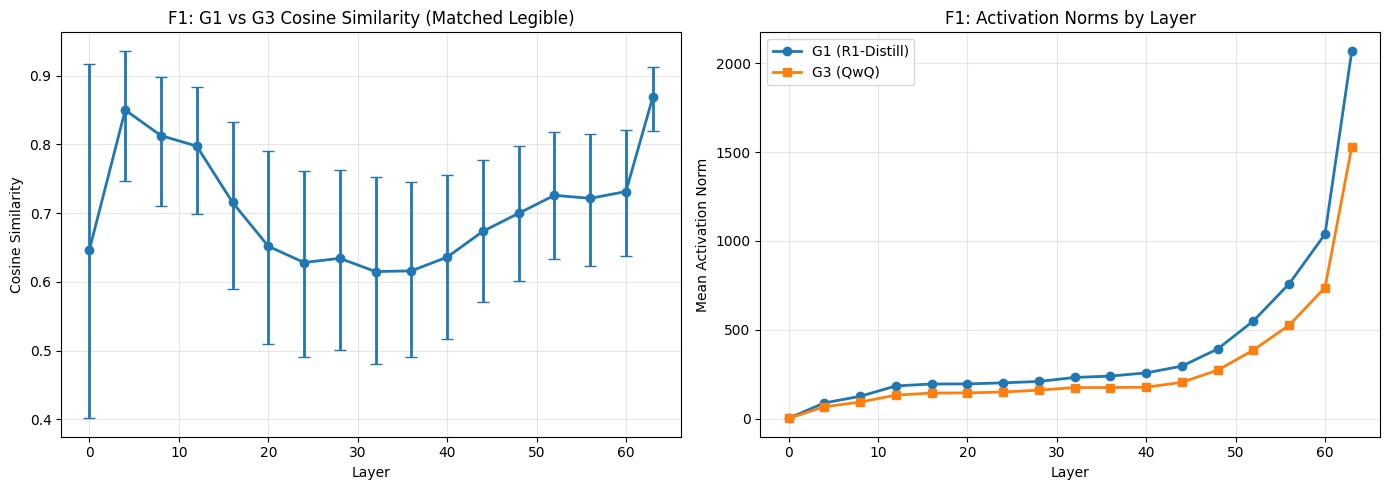

In [7]:
# Plot cosine similarity and norm comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Cosine similarity
layers = sorted(cosine_results.keys())
cos_vals = [cosine_results[l]['mean'] for l in layers]
cos_ci_lo = [cosine_results[l]['ci'][0] for l in layers]
cos_ci_hi = [cosine_results[l]['ci'][1] for l in layers]
yerr = [[v - lo for v, lo in zip(cos_vals, cos_ci_lo)],
        [hi - v for v, hi in zip(cos_vals, cos_ci_hi)]]

ax1.errorbar(layers, cos_vals, yerr=yerr, fmt='o-', capsize=4, linewidth=2)
ax1.set_xlabel('Layer')
ax1.set_ylabel('Cosine Similarity')
ax1.set_title('F1: G1 vs G3 Cosine Similarity (Matched Legible)')
ax1.grid(alpha=0.3)

# Norms
g1_norms_plot = [norm_results[l]['g1_mean_norm'] for l in layers]
g3_norms_plot = [norm_results[l]['g3_mean_norm'] for l in layers]
ax2.plot(layers, g1_norms_plot, 'o-', label='G1 (R1-Distill)', linewidth=2)
ax2.plot(layers, g3_norms_plot, 's-', label='G3 (QwQ)', linewidth=2)
ax2.set_xlabel('Layer')
ax2.set_ylabel('Mean Activation Norm')
ax2.set_title('F1: Activation Norms by Layer')
ax2.legend()
ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(str(PHASE2_RESULTS_DIR / 'f1_cosine_norm.png'), dpi=150, bbox_inches='tight')
plt.show()

## Experiment F2: Generator Identity Probe

Can we distinguish G1 from G3 activations during legible reasoning?
If so, the models use different internal strategies even when both produce legible output.

In [8]:
# Build dataset: G1 legible (label=1) vs G3 legible (label=0)
g1_legible_idx = [i for i, l in enumerate(g1_labels) if l == 'REASONING_LEGIBLE']
g3_legible_idx = [i for i, l in enumerate(g3_labels) if l == 'REASONING_LEGIBLE']

n_g1 = len(g1_legible_idx)
n_g3 = len(g3_legible_idx)
print(f"G1 legible: {n_g1}, G3 legible: {n_g3}")

# Need at least 10 per class
if n_g1 >= 5 and n_g3 >= 5:
    generator_probe_results = {}
    
    for layer_idx in common_layers:
        g1_feats = g1_last[layer_idx][g1_legible_idx]
        g3_feats = g3_last[layer_idx][g3_legible_idx]
        
        features = np.concatenate([g1_feats, g3_feats], axis=0)
        labels = np.array([1] * n_g1 + [0] * n_g3)
        
        n_splits = min(5, min(n_g1, n_g3))
        if n_splits < 2:
            continue
        
        result = train_binary_probe(features, labels, n_splits=n_splits)
        generator_probe_results[layer_idx] = result
        print(f"  Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} CI={result['auroc_ci']}")
    
    # Permutation test on best layer (1000 permutations)
    if generator_probe_results:
        best_layer = max(generator_probe_results, key=lambda k: generator_probe_results[k]['auroc'])
        features = np.concatenate([g1_last[best_layer][g1_legible_idx],
                                   g3_last[best_layer][g3_legible_idx]], axis=0)
        labels = np.array([1] * n_g1 + [0] * n_g3)
        perm = permutation_test(features, labels, n_permutations=1000)
        print(f"\nBest layer {best_layer}: p={perm['p_value']:.4f}")
else:
    print("Insufficient legible samples for generator identity probe")
    generator_probe_results = {}

G1 legible: 33, G3 legible: 30
  Layer   0: AUROC=0.976 CI=(0.9285714285714285, 1.0)
  Layer   4: AUROC=1.000 CI=(1.0, 1.0)
  Layer   8: AUROC=1.000 CI=(1.0, 1.0)
  Layer  12: AUROC=1.000 CI=(1.0, 1.0)
  Layer  16: AUROC=0.995 CI=(0.9857142857142858, 1.0)
  Layer  20: AUROC=1.000 CI=(1.0, 1.0)
  Layer  24: AUROC=0.995 CI=(0.9857142857142858, 1.0)
  Layer  28: AUROC=1.000 CI=(1.0, 1.0)
  Layer  32: AUROC=1.000 CI=(1.0, 1.0)
  Layer  36: AUROC=1.000 CI=(1.0, 1.0)
  Layer  40: AUROC=1.000 CI=(1.0, 1.0)
  Layer  44: AUROC=1.000 CI=(1.0, 1.0)
  Layer  48: AUROC=1.000 CI=(1.0, 1.0)
  Layer  52: AUROC=1.000 CI=(1.0, 1.0)
  Layer  56: AUROC=1.000 CI=(1.0, 1.0)
  Layer  60: AUROC=1.000 CI=(1.0, 1.0)
  Layer  63: AUROC=1.000 CI=(1.0, 1.0)

Best layer 4: p=0.0000


  Saved plot to /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/f2_generator_probe.png


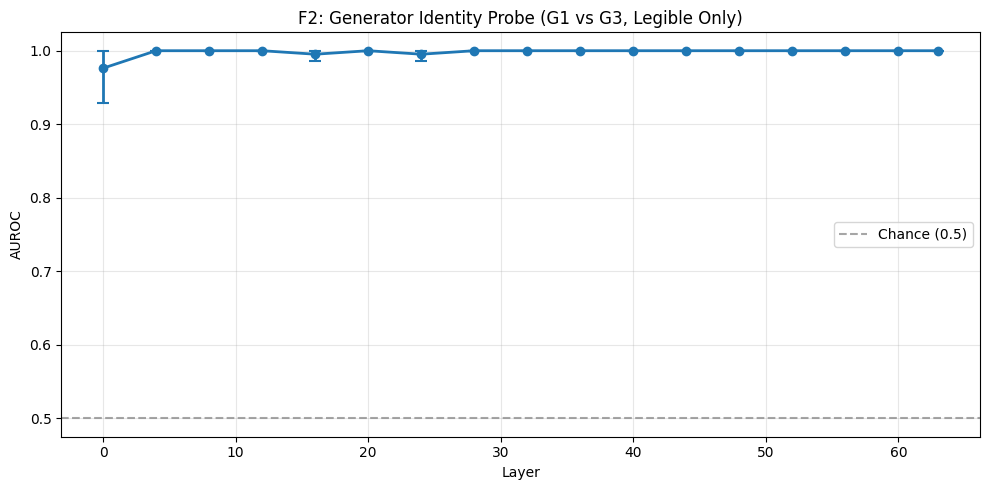

In [9]:
# Plot generator identity probe
if generator_probe_results:
    fig, ax = plot_layer_probe_curve(
        generator_probe_results,
        title='F2: Generator Identity Probe (G1 vs G3, Legible Only)',
        save_path=str(PHASE2_RESULTS_DIR / 'f2_generator_probe.png'),
    )
    plt.show()

In [10]:
# Foreignness covariate check for G1 vs G3 comparison
from phase2_utils import load_foreignness_scores, join_cots_with_labels

foreignness = load_foreignness_scores()

print("Foreignness covariate check (matched legible samples):")
for gid, matched_idx, sids in [
    ("G1", g1_matched_idx, g1_sids),
    ("G3", g3_matched_idx, g3_sids),
]:
    f_scores = []
    cots = join_cots_with_labels(labels=['REASONING_LEGIBLE'], generator_ids=[gid])
    cots_by_sid = {c['sample_id']: c for c in cots}
    for i in matched_idx[:n_match]:
        sid = sids[i]
        c = cots_by_sid.get(sid)
        if c:
            scores = []
            for rid in ['R1', 'R2', 'R3']:
                key = (c['sample_id'], c['generator_id'], c['epoch'], rid)
                if key in foreignness:
                    scores.append(foreignness[key])
            f_scores.append(np.mean(scores) if scores else np.nan)
        else:
            f_scores.append(np.nan)
    f_scores = np.array(f_scores)
    valid = np.isfinite(f_scores)
    if valid.any():
        print(f"  {gid}: mean_foreignness={np.nanmean(f_scores):.2f}, "
              f"std={np.nanstd(f_scores):.2f}, n={valid.sum()}")
    else:
        print(f"  {gid}: no foreignness data available")

# Save results
def clean(d):
    return {int(k): {kk: vv for kk, vv in v.items() if kk not in ('probe_model', 'scaler', 'pipeline')}
            for k, v in d.items()}

output = {
    'f1_cosine': {int(k): v for k, v in cosine_results.items()},
    'f1_norms': {int(k): v for k, v in norm_results.items()},
    'f2_generator_probe': clean(generator_probe_results),
    'n_matched_legible': n_match,
}
with open(PHASE2_RESULTS_DIR / 'narration_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)
print(f"Saved to {PHASE2_RESULTS_DIR / 'narration_results.json'}")

Foreignness covariate check (matched legible samples):
  G1: no foreignness data available
  G3: no foreignness data available
Saved to /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/narration_results.json
